In [ ]:
!mkdir -p /content/fashion_dataset
!unzip -q "/content/drive/MyDrive/Colab Notebooks/Glance Intern/val_test2020.zip" -d /content/fashion_dataset

In [ ]:
import os

image_dir='/content/fashion_dataset'
valid_extensions=('.jpg', '.jpeg', '.png', '.webp')

image_paths=[]
for root,dirs,files in os.walk(image_dir):
    for file in files:
        if file.lower().endswith(valid_extensions):
            image_paths.append(os.path.join(root, file))

print(f"Success! Total images extracted: {len(image_paths)}")

Success! Total images extracted: 3200


In [ ]:
!pip install -q transformers pillow chromadb sentence-transformers torch torchvision tqdm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.3/23.3 MB 61.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 20.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 83.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.7/18.7 MB 51.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.9/178.9 kB 15.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.9/61.9 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.7/203.7 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.6/71.6 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.7/61.7 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 6.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently 

In [ ]:
import os
import torch
import chromadb
from PIL import Image
from tqdm import tqdm
from transformers import BlipProcessor, BlipForConditionalGeneration

In [ ]:
device="cuda" if torch.cuda.is_available() else "cpu"

In [ ]:
processor=BlipProcessor.from_pretrained("Salesforce/blip-image-captioning-base")
model=BlipForConditionalGeneration.from_pretrained("Salesforce/blip-image-captioning-base").to(device)

preprocessor_config.json:   0%|          | 0.00/287 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/4.56k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/506 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/711k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/990M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

In [ ]:
chroma_client=chromadb.PersistentClient(path="/content/chroma_db")
collection=chroma_client.get_or_create_collection(name="fashion_index")

In [ ]:
chroma_client=chromadb.PersistentClient(path="/content/chroma_db")
collection=chroma_client.get_or_create_collection(name="fashion_index") # has default embedding

In [ ]:
image_paths=[]
for root,dirs,files in os.walk(image_dir):
    for file in files:
        if file.lower().endswith(valid_extensions):
            image_paths.append(os.path.join(root, file))

In [ ]:
len(image_paths)

3200

In [ ]:
batch_size=1
docs=[]
metadatas=[]
ids=[]

for i,img_path in enumerate(tqdm(image_paths)):
    try:
        raw_image=Image.open(img_path).convert('RGB')

        inputs=processor(raw_image, return_tensors="pt").to(device)
        out=model.generate(**inputs, max_new_tokens=30)
        caption=processor.decode(out[0], skip_special_tokens=True)

        docs.append(caption)
        metadatas.append({"image_path": img_path})
        ids.append(f"img_{i}")

        if len(docs)==50 or i==len(image_paths)-1:
            collection.add(
                documents=docs,
                metadatas=metadatas,
                ids=ids
            )
            docs=[]
            metadatas=[]
            ids=[]

    except Exception as e:
        print(f"Error processing {img_path}: {e}")
        continue

print("Indexing Complete! Your vector database is saved at /content/chroma_db")

  2%|▏         | 49/3200 [00:13<10:59,  4.78it/s]
/root/.cache/chroma/onnx_models/all-MiniLM-L6-v2/onnx.tar.gz:   0%|          | 0.00/79.3M [00:00<?, ?iB/s]
/root/.cache/chroma/onnx_models/all-MiniLM-L6-v2/onnx.tar.gz:   0%|          | 17.0k/79.3M [00:00<18:09, 76.3kiB/s]
/root/.cache/chroma/onnx_models/all-MiniLM-L6-v2/onnx.tar.gz:   0%|          | 53.0k/79.3M [00:00<11:02, 125kiB/s] 
/root/.cache/chroma/onnx_models/all-MiniLM-L6-v2/onnx.tar.gz:   0%|          | 155k/79.3M [00:00<05:02, 275kiB/s] 
/root/.cache/chroma/onnx_models/all-MiniLM-L6-v2/onnx.tar.gz:   0%|          | 342k/79.3M [00:00<02:47, 493kiB/s]
/root/.cache/chroma/onnx_models/all-MiniLM-L6-v2/onnx.tar.gz:   1%|          | 716k/79.3M [00:01<01:30, 913kiB/s]
/root/.cache/chroma/onnx_models/all-MiniLM-L6-v2/onnx.tar.gz:   2%|▏         | 1.43M/79.3M [00:01<00:47, 1.73MiB/s]
/root/.cache/chroma/onnx_models/all-MiniLM-L6-v2/onnx.tar.gz:   4%|▎         | 2.89M/79.3M [00:01<00:24, 3.32MiB/s]
/root/.cache/chroma/onnx_models/all-

Indexing Complete! Your vector database is saved at /content/chroma_db


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from PIL import Image
from IPython.display import display

chroma_client=chromadb.PersistentClient(path="/content/chroma_db")
collection=chroma_client.get_collection(name="fashion_index")

In [ ]:
collection=chroma_client.get_collection(name="fashion_index")
print(f"Total items indexed in Vector DB: {collection.count()}")

if collection.count() > 0:
    print("\nSample database entry:")
    peek=collection.peek(limit=2)
    print("Captions:",peek['documents'])
    print("Metadata:",peek['metadatas'])
else:
    print("\nYour vector database is completely empty. The indexing step did not save the items properly.")

Total items indexed in Vector DB: 3200

Sample database entry:
Captions: ['a woman standing on the side of a street', 'a model walks the runway at the show']
Metadata: [{'image_path': '/content/fashion_dataset/test/df304efac199ddc41d7bea387ed0b4e0.jpg'}, {'image_path': '/content/fashion_dataset/test/3ce04e48660ed6d21aee863f674486b7.jpg'}]


In [ ]:
def search_fashion_robust(query, top_k=3):
    print(f"Searching for: '{query}'\n")

    results=collection.query(
        query_texts=[query],
        n_results=top_k
    )

    captions=results['documents'][0]
    metadatas=results['metadatas'][0]
    distances=results['distances'][0]

    for i in range(len(metadatas)):
        img_path=metadatas[i]['image_path']
        caption=captions[i]
        dist=distances[i]

        print(f"Match #{i+1} (Distance: {dist:.4f})")
        print(f"Generated Caption: '{caption}'")
        print(f"Image Path: {img_path}")

        if os.path.exists(img_path):
            try:
                img=Image.open(img_path)
                img.thumbnail((300, 300))
                display(img)
            except Exception as e:
                print(f"Error displaying image: {e}")
        else:
            print(f"Error: File does not exist at path: {img_path}")
        print("-" *50)

Searching for: 'A person in a bright yellow raincoat.'

Match #1 (Distance: 0.6431)
Generated Caption: 'a woman in a yellow jacket and colorful pants'
Image Path: /content/fashion_dataset/test/7be5e15df33ddfd91374e7f3236b0933.jpg


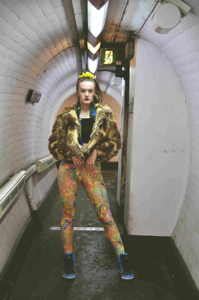

--------------------------------------------------
Match #2 (Distance: 0.6806)
Generated Caption: 'a little girl in a yellow raincoat and red tights'
Image Path: /content/fashion_dataset/test/e636280e96f3863157a4398c92fc299e.jpg


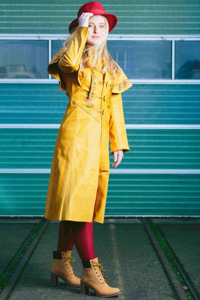

--------------------------------------------------
Match #3 (Distance: 0.7296)
Generated Caption: 'person in a yellow dress'
Image Path: /content/fashion_dataset/test/3b9cc0d697af512490a7bf58883f9a20.jpg


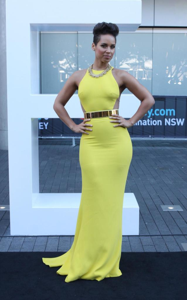

--------------------------------------------------


In [ ]:
search_fashion_robust("A person in a bright yellow raincoat.",top_k=3)

Searching for: 'Professional man in business attire inside a modern office.'

Match #1 (Distance: 1.1780)
Generated Caption: 'a man in a suit and tie standing on a white carpet'
Image Path: /content/fashion_dataset/test/913109abff6b0222d9afed1c7aaeb38f.jpg


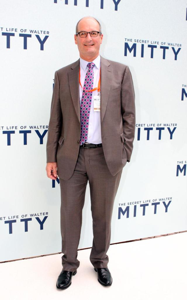

--------------------------------------------------
Match #2 (Distance: 1.2240)
Generated Caption: 'a model wears a creation by designer and designer, who is wearing a dress made from newspaper pages'
Image Path: /content/fashion_dataset/test/e73b13b557ab167a05cb10ed45decf52.jpg


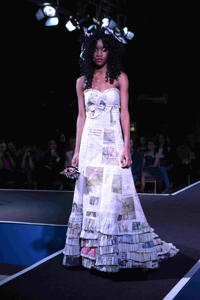

--------------------------------------------------
Match #3 (Distance: 1.2356)
Generated Caption: 'a model in a leather dress'
Image Path: /content/fashion_dataset/test/4f55ee2a4882753c0d92a1529c2def3f.jpg


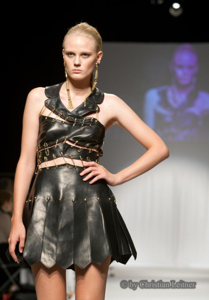

--------------------------------------------------


In [ ]:
search_fashion_robust("Professional man in business attire inside a modern office.", top_k=3)

Searching for: 'Someone wearing a blue shirt sitting on a park bench.'

Match #1 (Distance: 0.6317)
Generated Caption: 'a woman sitting on a bench in the park'
Image Path: /content/fashion_dataset/test/8c600039c2a2abf0caa5c632f2694fcb.jpg


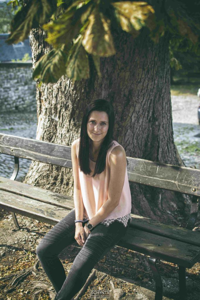

--------------------------------------------------
Match #2 (Distance: 0.6343)
Generated Caption: 'a woman sitting on a bench in a park'
Image Path: /content/fashion_dataset/test/ba3d56d9c653a0ee7edd0efe284b20a2.jpg


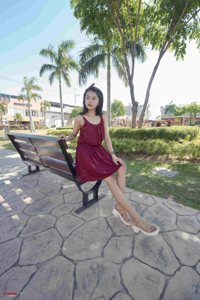

--------------------------------------------------
Match #3 (Distance: 0.6343)
Generated Caption: 'a woman sitting on a bench in a park'
Image Path: /content/fashion_dataset/test/5ad73b4c6c594d222bd5626b220ce323.jpg


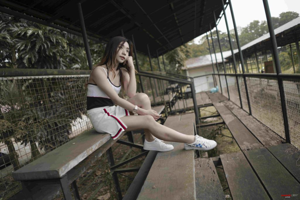

--------------------------------------------------


In [ ]:
search_fashion_robust("Someone wearing a blue shirt sitting on a park bench.", top_k=3)

Searching for: 'A red tie and a white shirt in a formal setting.'

Match #1 (Distance: 1.2304)
Generated Caption: 'person in red boots and a white shirt'
Image Path: /content/fashion_dataset/test/086d00c234f4cb9aa9798860266c3c3f.jpg


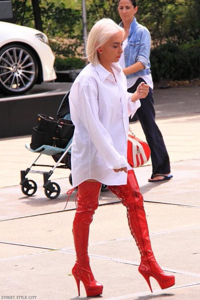

--------------------------------------------------
Match #2 (Distance: 1.2459)
Generated Caption: 'a model in a leather dress'
Image Path: /content/fashion_dataset/test/4f55ee2a4882753c0d92a1529c2def3f.jpg


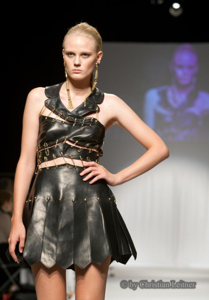

--------------------------------------------------
Match #3 (Distance: 1.2488)
Generated Caption: 'person in a burgundy gown'
Image Path: /content/fashion_dataset/test/62bf650d4eaa67745e0bc3104ac588b9.jpg


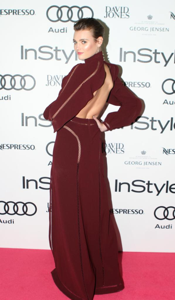

--------------------------------------------------


In [ ]:
search_fashion_robust("A red tie and a white shirt in a formal setting.", top_k=3)